Exericese II: Threshold Exceedances and GPD

Download same data and calculate log return

In [3]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
import yfinance as yf
import numpy as np
from scipy.stats import genextreme
import pandas as pd

nikkei = yf.download('^N225', start='2015-10-18', end='2025-10-18')
close = nikkei['Close']

# log-returns (daily), drop the NaN
ret = np.log(close / close.shift(1)).dropna()
print(len(ret))

[*********************100%***********************]  1 of 1 completed

2443


1. Create a sample mean excess plot for the losses (negative returns).

    Identify an appropriate threshold u where the plot appears approximately linear.

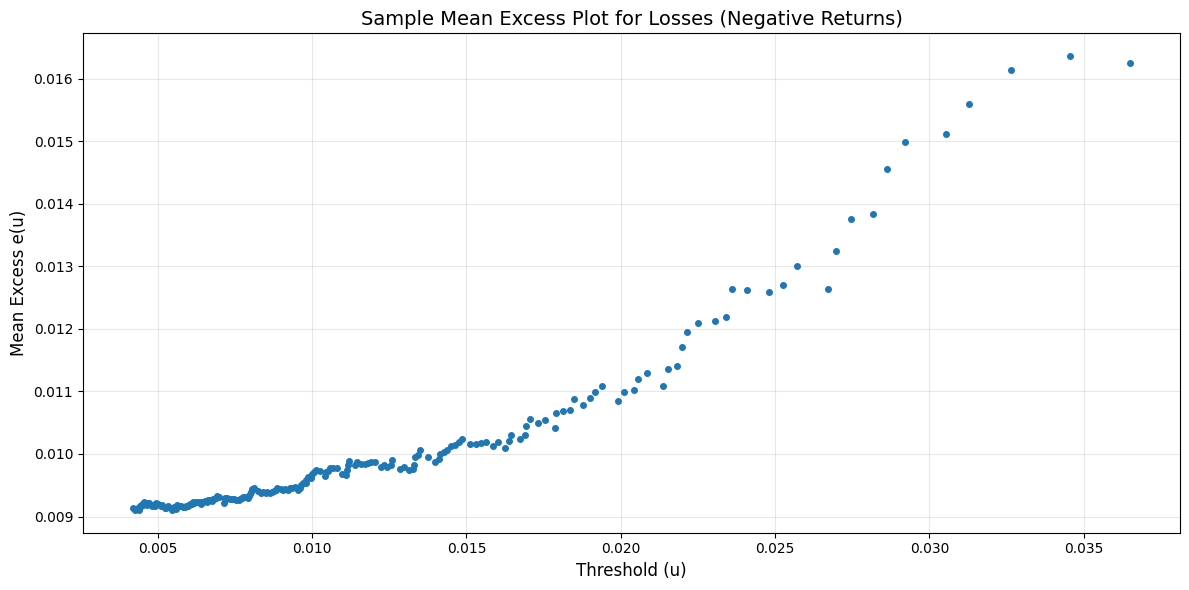

Threshold range: [0.0042, 0.0365]


In [42]:
import matplotlib.pyplot as plt
from scipy import stats

# Convert returns to losses (negative returns)
losses = np.maximum(-ret, 0)

# Sort the losses in ascending order
sorted_losses = np.sort(losses.values)

# Function to calculate mean excess for a given threshold
def mean_excess(data, threshold):
    exceedances = data[data > threshold]
    if len(exceedances) > 0:
        return np.mean(exceedances - threshold)
    else:
        return np.nan

# Create a range of thresholds (using percentiles)
percentiles = np.linspace(70, 99, 200)
thresholds = np.percentile(sorted_losses, percentiles)

# Calculate mean excess for each threshold
mean_excesses = np.array([mean_excess(sorted_losses, u) for u in thresholds])

# Plot the sample mean excess function
plt.figure(figsize=(12, 6))
plt.plot(thresholds, mean_excesses, 'o', markersize=4, linewidth=1.5)
plt.grid(True, alpha=0.3)
plt.xlabel('Threshold (u)', fontsize=12)
plt.ylabel('Mean Excess e(u)', fontsize=12)
plt.title('Sample Mean Excess Plot for Losses (Negative Returns)', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Threshold range: [{thresholds.min():.4f}, {thresholds.max():.4f}]')

2. For your chosen threshold u, fit a Generalized Pareto Distribution (GPD) to the exceedances using maximum likelihood. Report ξˆ and βˆ with standard errors (number of exceedances, Variance).

In [5]:
from scipy.stats import genpareto

# Select the optimal threshold directly
u_optimal = 0.026

# Extract exceedances over the optimal threshold
exceedances = sorted_losses[sorted_losses > u_optimal]
exceedances_centered = exceedances - u_optimal

# Fit GPD using scipy.stats.genpareto
params_fit = genpareto.fit(exceedances_centered, floc=0)
xi_mle = params_fit[0]
beta_mle = params_fit[2]

# Compute standard errors using bootstrap
np.random.seed(42)
xi_boot = []
beta_boot = []

for _ in range(1000):
    indices = np.random.choice(len(exceedances_centered), size=len(exceedances_centered), replace=True)
    boot_sample = exceedances_centered[indices]
    try:
        params_boot = genpareto.fit(boot_sample, floc=0)
        xi_boot.append(params_boot[0])
        beta_boot.append(params_boot[2])
    except:
        pass

se_xi = np.std(xi_boot)
se_beta = np.std(beta_boot)

print(f"Number of exceedances: {len(exceedances)}")
print(f"Proportion of exceedances: {len(exceedances)/len(sorted_losses):.4f}")       
# Print in table format
print("=" * 60)
print(f"GPD Parameter Estimates (u = {u_optimal:.4f})")
print("=" * 60)
print(f"{'Parameter':<25} {'Estimate':<15} {'Std. Error':<15}")
print("-" * 60)
print(f"{'Shape (ξ̂)':<20} {xi_mle:>14.6f} {se_xi:>14.6f}")
print(f"{'Scale (β̂)':<20} {beta_mle:>14.6f} {se_beta:>14.6f}")
print("=" * 60)

Number of exceedances: 63
Proportion of exceedances: 0.0258
GPD Parameter Estimates (u = 0.0260)
Parameter                 Estimate        Std. Error     
------------------------------------------------------------
Shape (ξ̂)                 0.269576       0.186431
Scale (β̂)                 0.009537       0.002290


3. Implement a threshold stability plot: for a range of thresholds from the 90th to 99th percentile of losses, fit GPD models and plot:

    • ξˆ versus threshold (with confidence bands)

    • Modified scale parameter βˆ − ξuˆ versus threshold

    Discuss the stability of your parameter estimates.

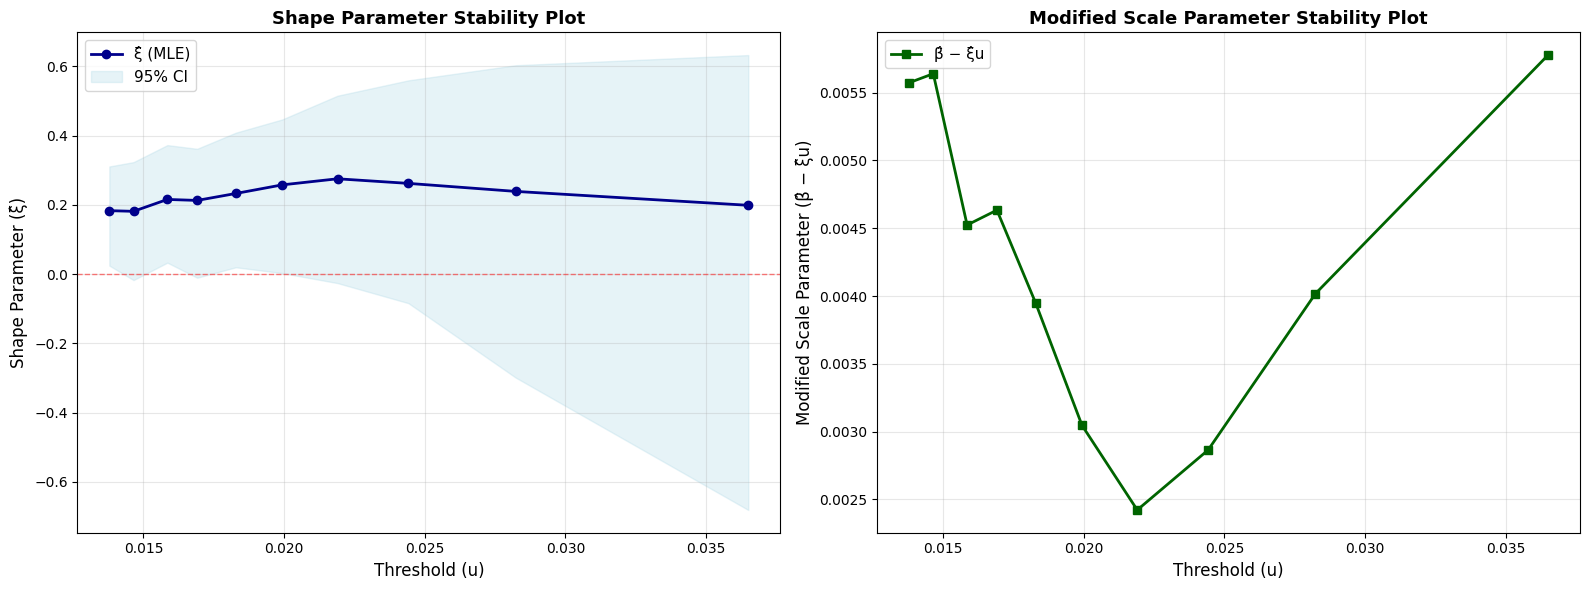

THRESHOLD STABILITY ANALYSIS
Threshold Range           0.013790 to 0.036504
Number of thresholds      10

Shape Parameter (ξ̂) Statistics:
  Mean                      0.225878
  Std Dev                   0.031305
  Range                   [ 0.181341,  0.275319]

Modified Scale Parameter Statistics:
  Mean                      0.004245
  Std Dev                   0.001144
  Range                   [ 0.002422,  0.005777]

Stability Discussion:
✓ Shape parameter ξ̂ is relatively stable across thresholds (CV < 0.2)
✗ Modified scale parameter shows moderate to high variation across thresholds


In [45]:
# Threshold stability plot
from scipy.stats import genpareto

# Define threshold range (90th to 99th percentile)
percentile_range = np.linspace(90, 99, 10)
thresholds_stability = np.percentile(sorted_losses, percentile_range)

# Storage for results
xi_estimates = []
beta_estimates = []
modified_scale = []
xi_lower_ci = []
xi_upper_ci = []
beta_lower_ci = []
beta_upper_ci = []

# For each threshold, fit GPD and compute bootstrap confidence intervals
np.random.seed(42)
for u in thresholds_stability:
    exceedances_u = sorted_losses[sorted_losses > u]
    exceedances_centered_u = exceedances_u - u
    
    # MLE fit
    params_fit = genpareto.fit(exceedances_centered_u, floc=0)
    xi = params_fit[0]
    beta = params_fit[2]
    
    xi_estimates.append(xi)
    beta_estimates.append(beta)
    modified_scale.append(beta - xi * u)
    
    # Bootstrap for confidence intervals
    xi_boot_temp = []
    beta_boot_temp = []
    
    for _ in range(500):
        indices = np.random.choice(len(exceedances_centered_u), size=len(exceedances_centered_u), replace=True)
        boot_sample = exceedances_centered_u[indices]
        try:
            params_boot = genpareto.fit(boot_sample, floc=0)
            xi_boot_temp.append(params_boot[0])
            beta_boot_temp.append(params_boot[2])
        except:
            pass
    
    # 95% confidence intervals
    xi_lower_ci.append(np.percentile(xi_boot_temp, 2.5))
    xi_upper_ci.append(np.percentile(xi_boot_temp, 97.5))
    beta_lower_ci.append(np.percentile(beta_boot_temp, 2.5))
    beta_upper_ci.append(np.percentile(beta_boot_temp, 97.5))

# Convert to arrays
xi_estimates = np.array(xi_estimates)
beta_estimates = np.array(beta_estimates)
modified_scale = np.array(modified_scale)
xi_lower_ci = np.array(xi_lower_ci)
xi_upper_ci = np.array(xi_upper_ci)
beta_lower_ci = np.array(beta_lower_ci)
beta_upper_ci = np.array(beta_upper_ci)

# Create two-panel plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: ξ̂ versus threshold with confidence bands
ax1.plot(thresholds_stability, xi_estimates, 'o-', linewidth=2, markersize=6, label='ξ̂ (MLE)', color='darkblue')
ax1.fill_between(thresholds_stability, xi_lower_ci, xi_upper_ci, alpha=0.3, color='lightblue', label='95% CI')
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('Threshold (u)', fontsize=12)
ax1.set_ylabel('Shape Parameter (ξ̂)', fontsize=12)
ax1.set_title('Shape Parameter Stability Plot', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)

# Plot 2: Modified scale parameter versus threshold
ax2.plot(thresholds_stability, modified_scale, 's-', linewidth=2, markersize=6, label='β̂ − ξ̂u', color='darkgreen')
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Threshold (u)', fontsize=12)
ax2.set_ylabel('Modified Scale Parameter (β̂ − ξ̂u)', fontsize=12)
ax2.set_title('Modified Scale Parameter Stability Plot', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Summary statistics
print("=" * 70)
print("THRESHOLD STABILITY ANALYSIS")
print("=" * 70)
print(f"{'Threshold Range':<25} {thresholds_stability.min():.6f} to {thresholds_stability.max():.6f}")
print(f"{'Number of thresholds':<25} {len(thresholds_stability)}")
print("\nShape Parameter (ξ̂) Statistics:")
print(f"{'  Mean':<25} {np.mean(xi_estimates):>10.6f}")
print(f"{'  Std Dev':<25} {np.std(xi_estimates):>10.6f}")
print(f"{'  Range':<25} [{np.min(xi_estimates):>9.6f}, {np.max(xi_estimates):>9.6f}]")
print("\nModified Scale Parameter Statistics:")
print(f"{'  Mean':<25} {np.mean(modified_scale):>10.6f}")
print(f"{'  Std Dev':<25} {np.std(modified_scale):>10.6f}")
print(f"{'  Range':<25} [{np.min(modified_scale):>9.6f}, {np.max(modified_scale):>9.6f}]")
print("=" * 70)
print("\nStability Discussion:")
if np.std(xi_estimates) / np.mean(np.abs(xi_estimates)) < 0.2:
    print("✓ Shape parameter ξ̂ is relatively stable across thresholds (CV < 0.2)")
else:
    print("✗ Shape parameter ξ̂ shows moderate to high variation across thresholds")
    
if np.std(modified_scale) / np.mean(modified_scale) < 0.2:
    print("✓ Modified scale parameter is relatively stable across thresholds (CV < 0.2)")
else:
    print("✗ Modified scale parameter shows moderate to high variation across thresholds")

4. Using your fitted GPD model, estimate:

    • VaR_0.99 and VaR_0.995 for daily losses
    
    • ES_0.99 and ES_0.995 for daily losses

In [7]:
# Considering the linearity, number of exceedances, SE(Variance), and stability, 
# we finally chose the 0.026 as the optimal threshold.
# Select the specific threshold

# Extract exceedances over the optimal threshold
exceedances = sorted_losses[sorted_losses > u_optimal]
exceedances_centered = exceedances - u_optimal

# Fit GPD using scipy.stats.genpareto
params_fit = genpareto.fit(exceedances_centered, floc=0)
xi_mle = params_fit[0]
beta_mle = params_fit[2]

# Parameters from the fit
n_total = len(sorted_losses)
n_exceed = len(exceedances)
prob_exceed = n_exceed / n_total

# Confidence levels for VaR and ES
confidence_levels = [0.99, 0.995]

print("=" * 70)
print("VALUE AT RISK (VaR) AND EXPECTED SHORTFALL (ES) ESTIMATION")
print("=" * 70)
print(f"  Sample size: {n_total}")
print(f"\nGPD Parameters (u = {u_optimal}):")
print(f"  Shape (ξ̂): {xi_mle:.6f}")
print(f"  Scale (β̂): {beta_mle:.6f}")
print(f"  Threshold (u): {u_optimal:.6f}")
print(f"  Number of exceedances: {n_exceed}")
print(f"  Probability of exceedance: {prob_exceed:.6f}")

# Create GPD distribution object
gpd_dist = genpareto(c=xi_mle, loc=0, scale=beta_mle)

# Function to calculate VaR using GPD
def var_gpd(p, gpd_dist, u, prob_exceed):

    if p <= (1 - prob_exceed):
        # For probabilities below threshold, use empirical quantile
        return np.percentile(sorted_losses, p * 100)
    
    # Conditional probability in the tail
    p_conditional = (1 - p) / prob_exceed
    
    # Use ppf (percent point function / inverse CDF) to get quantile
    excess_quantile = gpd_dist.ppf(1 - p_conditional)
    
    # VaR is threshold plus the excess quantile
    var = u + excess_quantile
    
    return var

# Function to calculate ES using GPD
def es_gpd(p, xi, beta, u, prob_exceed, var_value):

    if xi >= 1:
        return np.inf
    
    # ES formula for GPD
    es = (var_value + beta - xi * u) / (1 - xi)
    
    return es

# Calculate VaR and ES for each confidence level
results = []
for p in confidence_levels:
    var = var_gpd(p, gpd_dist, u_optimal, prob_exceed)
    es = es_gpd(p, xi_mle, beta_mle, u_optimal, prob_exceed, var)
    results.append({'confidence': p, 'var': var, 'es': es})

print("\n" + "=" * 70)
print(f"{'Confidence':<15} {'VaR':<20} {'ES':<20}")
print("-" * 70)
for res in results:
    print(f"{res['confidence']*100:>6.1f}%{'':<8} {res['var']:>8.6f} {res['es']:>18.6f}")
print("=" * 70)

# Optional: Compare with empirical quantiles
print("Comparison with Empirical Quantiles:")
print("-" * 70)
for i, p in enumerate(confidence_levels):
    empirical_quantile = np.percentile(sorted_losses, p * 100)
    var = results[i]['var']
    print(f"Confidence {p*100:.1f}%:")
    print(f"  Empirical quantile: {empirical_quantile:.6f}")
    print(f"  GPD-based VaR:      {var:.6f}")
    print(f"  Difference:         {var - empirical_quantile:.6f}")

VALUE AT RISK (VaR) AND EXPECTED SHORTFALL (ES) ESTIMATION
  Sample size: 2443

GPD Parameters (u = 0.026):
  Shape (ξ̂): 0.269576
  Scale (β̂): 0.009537
  Threshold (u): 0.026000
  Number of exceedances: 63
  Probability of exceedance: 0.025788

Confidence      VaR                  ES                  
----------------------------------------------------------------------
  99.0%         0.036293           0.053148
  99.5%         0.045676           0.065994
Comparison with Empirical Quantiles:
----------------------------------------------------------------------
Confidence 99.0%:
  Empirical quantile: 0.036504
  GPD-based VaR:      0.036293
  Difference:         -0.000211
Confidence 99.5%:
  Empirical quantile: 0.046172
  GPD-based VaR:      0.045676
  Difference:         -0.000497


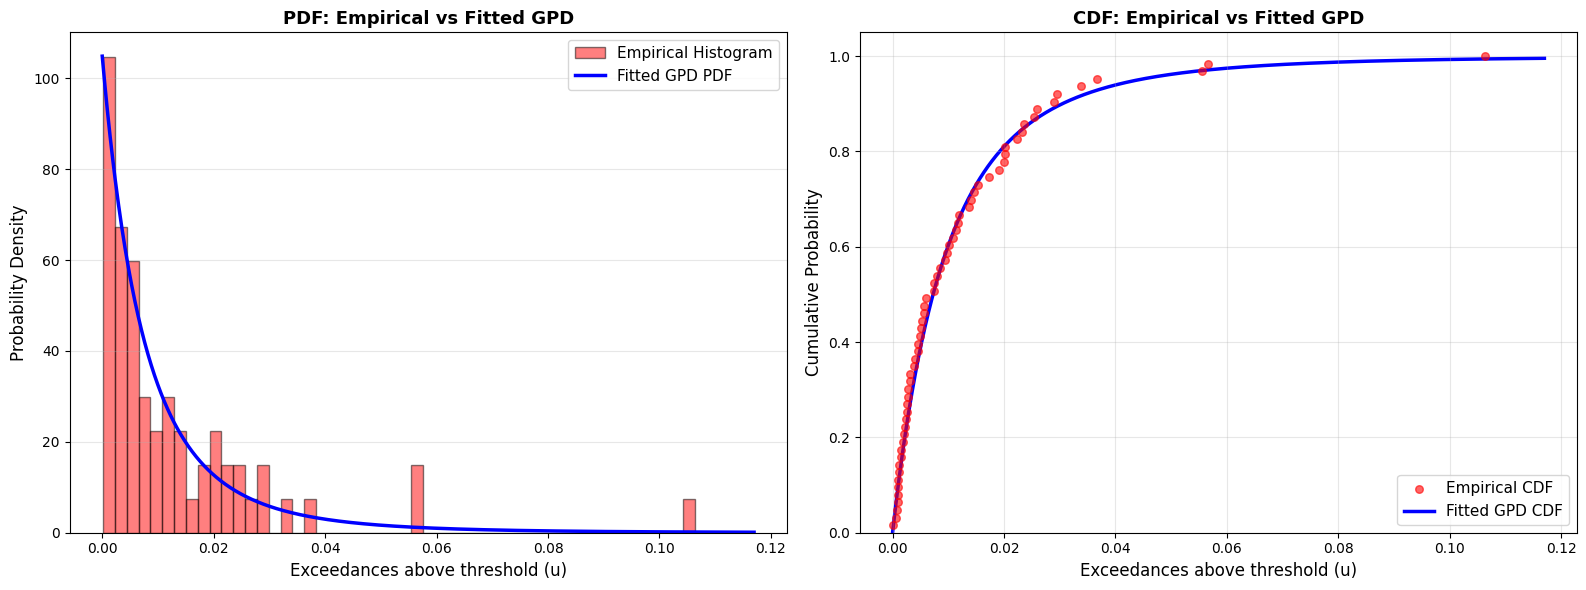

In [46]:
# Plot fitted GPD distribution vs empirical data

# Extract exceedances over threshold
exceedances = sorted_losses[sorted_losses > u_optimal]
exceedances_centered = exceedances - u_optimal

# Create x values for the fitted GPD curve
x_max = np.max(exceedances_centered)
x_range = np.linspace(0, x_max * 1.1, 1000)

# Calculate CDF and PDF of fitted GPD
gpd_cdf = gpd_dist.cdf(x_range)
gpd_pdf = gpd_dist.pdf(x_range)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Empirical vs Fitted PDF (Histogram)
counts, bins, patches = ax1.hist(exceedances_centered, bins=50, density=True, alpha=0.5, 
                                   color='red', edgecolor='black', label='Empirical Histogram', zorder=1)
ax1.plot(x_range, gpd_pdf, color='blue', linewidth=2.5, label='Fitted GPD PDF', zorder=2)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xlabel('Exceedances above threshold (u)', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.set_title('PDF: Empirical vs Fitted GPD', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')

# Plot 2: Empirical vs Fitted CDF
empirical_cdf = np.arange(1, len(exceedances_centered) + 1) / len(exceedances_centered)
ax2.scatter(np.sort(exceedances_centered), empirical_cdf, color='red', alpha=0.6, s=30, label='Empirical CDF', zorder=2)
ax2.plot(x_range, gpd_cdf, color='blue', linewidth=2.5, label='Fitted GPD CDF', zorder=1)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Exceedances above threshold (u)', fontsize=12)
ax2.set_ylabel('Cumulative Probability', fontsize=12)
ax2.set_title('CDF: Empirical vs Fitted GPD', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='lower right')
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

Exercise III：POT Model and Risk Estimation

1. Implement the Peaks-Over-Threshold (POT) model for your data:

    • Count the number of exceedances N_u for your chosen threshold

    • Estimate the exceedance rate λ = N_u/n

    • Combine with your GPD parameters to construct the POT model

In [9]:
# Use existing variables from previous analysis
# u_optimal, exceedances, exceedances_centered, xi_mle, beta_mle, n_exceed, prob_exceed, sorted_losses, n_total

# 1. Count the number of exceedances N_u
N_u = n_exceed

# 2. Exceedance rate λ = N_u/n
# 3. Construct the POT model
pot_model = {
    'threshold': u_optimal,
    'shape': xi_mle,
    'scale': beta_mle,
    'exceedance_rate': prob_exceed,
    'n_exceedances': N_u,
    'n_total': n_total
}

print("=" * 40)
print("         POT MODEL CONSTRUCTION")
print("=" * 40)
print(f"{'Parameter':<30} {'Value':<20}")
print("-" * 40)
print(f"{'Threshold (u)':<30} {pot_model['threshold']:.6f}")
print(f"{'Shape (ξ)':<30} {pot_model['shape']:.6f}")
print(f"{'Scale (β)':<30} {pot_model['scale']:.6f}")
print(f"{'Exceedance rate (λ)':<30} {pot_model['exceedance_rate']:.6f}")
print(f"{'Number of exceedances':<30} {pot_model['n_exceedances']}")
print(f"{'Total observations':<30} {pot_model['n_total']}")
print("=" * 40)

         POT MODEL CONSTRUCTION
Parameter                      Value               
----------------------------------------
Threshold (u)                  0.026000
Shape (ξ)                      0.269576
Scale (β)                      0.009537
Exceedance rate (λ)            0.025788
Number of exceedances          63
Total observations             2443


2. Using the POT model, calculate the k-day ahead VaR and ES at the 99% level for k = 1, 10, 20 days. 


In [10]:
alpha = 0.99
k_values = [1, 10, 20]

def var_k_day(alpha, k, u, xi, beta, lam):
    tail_prob = 1 - alpha**(1 / k)
    if tail_prob <= 0:
        raise ValueError('Tail probability must be positive.')
    if abs(xi) < 1e-8:
        return u + beta * np.log(lam / tail_prob)
    return u + (beta / xi) * ((lam / tail_prob)**xi - 1)

def es_from_var(var, u, xi, beta):
    if xi >= 1:
        return np.inf
    if abs(xi) < 1e-8:
        return var + beta
    return (var + beta - xi * u) / (1 - xi)

results = []
for k in k_values:
    var_k = var_k_day(alpha, k, u_optimal, xi_mle, beta_mle, prob_exceed)
    es_k = es_from_var(var_k, u_optimal, xi_mle, beta_mle)
    results.append({'k': k, 'VaR_0.99': var_k, 'ES_0.99': es_k})

print("=" * 50)
print("         K-DAY 99% VaR AND ES")
print("=" * 50)
print(f"{'Horizon (days)':<18}{'VaR_0.99':>16}{'ES_0.99':>16}")
print("-" * 50)
for res in results:
    print(f"{res['k']:<18}{res['VaR_0.99']:>16.6f}{res['ES_0.99']:>16.6f}")
print("=" * 50)

         K-DAY 99% VaR AND ES
Horizon (days)            VaR_0.99         ES_0.99
--------------------------------------------------
1                         0.036293        0.053148
10                        0.075477        0.106794
20                        0.092904        0.130652


3. Perform a simulation study:

    • Generate 10,000 one-year scenarios (250 trading days) from your fitted POT model

    • For each scenario, calculate the annual maximum loss

    • Compare the empirical distribution of annual maxima with the theoretical GEV distribution from Exercise I

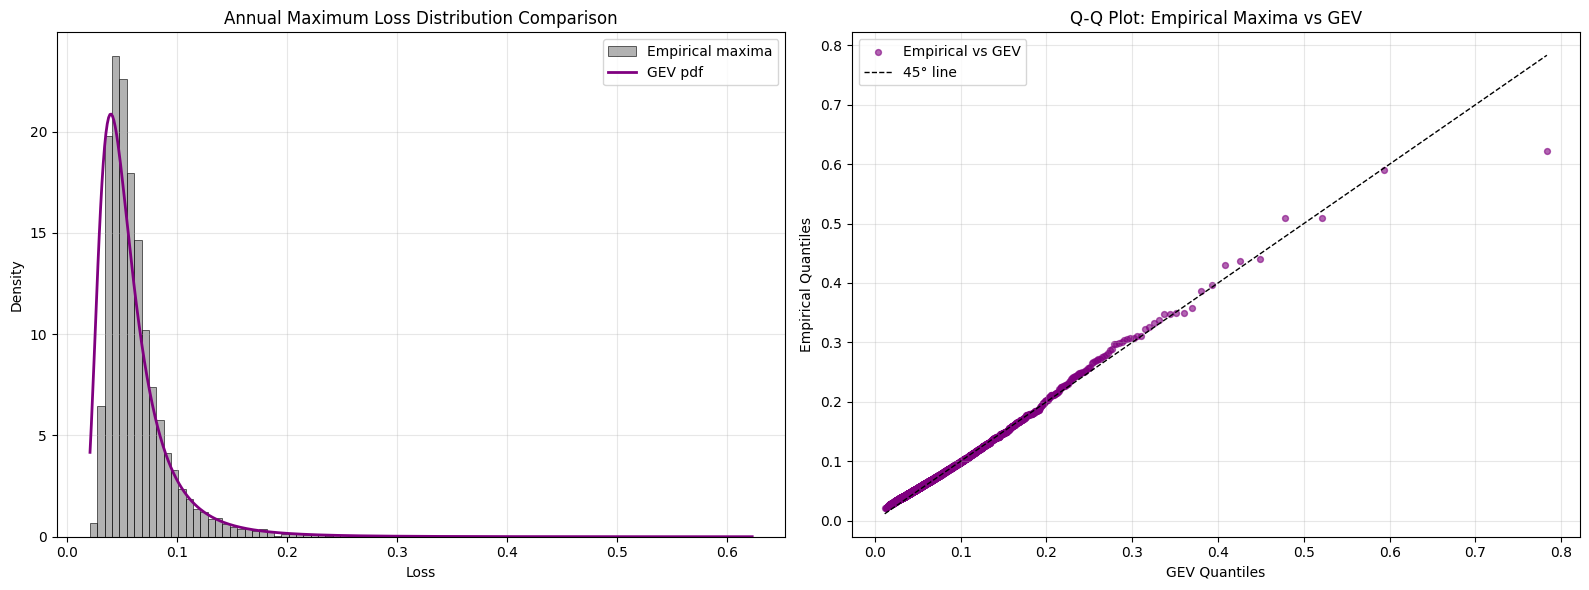

ANNUAL MAXIMUM LOSS ANALYSIS VIA POT SIMULATION
Number of simulated scenarios: 10000
KS statistic: 0.1457
KS p-value : 0.0000
------------------------------------------------------------
Empirical annual maxima summary:
mean    0.063386
std     0.034154
min     0.020752
25%     0.043861
50%     0.054730
75%     0.071348
max     0.622471
dtype: float64


In [31]:
# parameters of GEV distribution from Exercise I (block size 250)
GEV_xi = 0.2406 
GEV_mu = 0.0434 
GEV_sigma = 0.0181

n_scenarios = 10000
horizon = 250

np.random.seed(42)
subthreshold_losses = sorted_losses[sorted_losses <= u_optimal]

def simulate_daily_losses(n_days):
    indicators = np.random.rand(n_days) < prob_exceed
    losses = np.empty(n_days)
    losses[indicators] = u_optimal + genpareto.rvs(c=xi_mle, loc=0, scale=beta_mle, size=indicators.sum())
    losses[~indicators] = np.random.choice(subthreshold_losses, size=(~indicators).sum(), replace=True)
    return losses

max_losses = np.array([simulate_daily_losses(horizon).max() for _ in range(n_scenarios)])

gev_dist = genextreme(c=-GEV_xi, loc=GEV_mu, scale=GEV_sigma)
ks_stat, ks_pvalue = stats.kstest(max_losses, gev_dist.cdf)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].hist(max_losses, bins=90, density=True, alpha=0.6, color="grey", edgecolor="black", linewidth=0.7, label="Empirical maxima")
x_vals = np.linspace(max_losses.min(), max_losses.max(), 500)
axes[0].plot(x_vals, gev_dist.pdf(x_vals), color="purple", linewidth=2, label="GEV pdf")
axes[0].set_title("Annual Maximum Loss Distribution Comparison")
axes[0].set_xlabel("Loss")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(alpha=0.3)

sorted_empirical = np.sort(max_losses)
probs = (np.arange(1, len(sorted_empirical) + 1) - 0.5) / len(sorted_empirical)
theoretical_quantiles = gev_dist.ppf(probs)
axes[1].scatter(theoretical_quantiles, sorted_empirical, s=18, color="purple", alpha=0.6, label="Empirical vs GEV")
axes[1].plot(theoretical_quantiles, theoretical_quantiles, color="black", linestyle="--", linewidth=1, label="45° line")
axes[1].set_title("Q-Q Plot: Empirical Maxima vs GEV")
axes[1].set_xlabel("GEV Quantiles")
axes[1].set_ylabel("Empirical Quantiles")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 60)
print("ANNUAL MAXIMUM LOSS ANALYSIS VIA POT SIMULATION")
print("=" * 60)
print(f"Number of simulated scenarios: {n_scenarios}")
print(f"KS statistic: {ks_stat:.4f}")
print(f"KS p-value : {ks_pvalue:.4f}")
print("-" * 60)
print("Empirical annual maxima summary:")
print(pd.Series(max_losses).describe()[["mean", "std", "min", "25%", "50%", "75%", "max"]])

4. Implement a simple backtest: using the first 80% of your data for model fitting and the remaining 20% for testing, count the number of VaR violations at the 99% level. 
    
    Perform Kupiec’s test and comment on model adequacy.

In [40]:
from scipy.stats import chi2

# 1) Time-based split (preserve chronological order; do not sort)
split_idx = int(0.8 * len(losses))
train_losses = np.asarray(losses[:split_idx])  # chronological training set
test_losses  = np.asarray(losses[split_idx:])  # chronological test set

# 2) Training: choose threshold and fit GPD (use the same percentile as stability analysis)
u_train = np.percentile(train_losses, 97.5)
exceed_train = train_losses[train_losses > u_train]
y_train = exceed_train - u_train

# GPD MLE fit (fix loc=0 for exceedances)
c, loc, scale = genpareto.fit(y_train, floc=0)
xi_train, beta_train = c, scale

n_train = train_losses.size
n_exc   = y_train.size
lambda_train = n_exc / n_train  # exceedance rate

# 3) Compute 99% VaR using POT (unconditional) with training parameters
p = 0.99
if p <= (1 - lambda_train):
    var_99_train = np.quantile(train_losses, p)
else:
    if np.isclose(xi_train, 0.0):
        var_99_train = u_train + beta_train * np.log(lambda_train / (1 - p))
    else:
        var_99_train = u_train + (beta_train / xi_train) * ((lambda_train / (1 - p))**xi_train - 1)

# 4) Testing: count violations
violations = int(np.sum(test_losses > var_99_train))
n_test = test_losses.size
p_hat = violations / n_test
alpha = 0.99
p0 = 1 - alpha  # expected violation rate (1%)
exp_viol = p0 * n_test

# 5) Kupiec POF test (binomial likelihood ratio)
#    LR = -2 [ ln L(p0) - ln L(p_hat) ], where L(p) = p^x (1-p)^(n-x)
eps = 1e-12
ph = min(max(p_hat, eps), 1 - eps)
LR = -2 * (violations*np.log(p0/ph) + (n_test-violations)*np.log((1-p0)/(1-ph)))
p_value = 1 - chi2.cdf(LR, df=1)

# 6) Reporting
print("=" * 74)
print("BACKTEST: VaR MODEL VALIDATION (KUPIEC'S POF TEST)")
print("=" * 74)
print(f"Train/Test sizes           : {n_train:,}/{n_test:,}")
print(f"Threshold u (train)        : {u_train:.6f}")
print("GPD parameters:")
print(f"  Shape (ξ)                : {xi_train:.6f}")
print(f"  Scale (β)                : {beta_train:.6f}")
print(f"Exceedances (count)        : {n_exc:,}")
print(f"Exceedance rate (λ)        : {lambda_train:.6f}")
print("-" * 74)
print(f"VaR_0.99 (train-based)     : {var_99_train:.6f}")
print(f"Test violations (count)    : {violations:,}")
print(f"Expected violations        : {exp_viol:.2f}")
print(f"Observed violation rate    : {p_hat:.4%}")
print(f"Expected violation rate    : {p0:.2%}")
print("-" * 74)
print(f"Kupiec LR statistic        : {LR:.4f}")
print(f"p-value (df=1)             : {p_value:.4f}")
print("=" * 74)
if p_value >= 0.05:

    print("Result: Fail to reject H0 — coverage consistent with 1% at 5% level.")
    print("        Model is adequate.")
else:

    print("Result: Reject H0 — coverage inconsistent with 1% at 5% level.")
    print("  Too many violations → underestimation" if p_hat > p0 else
          "  Too few violations  → overestimation")
    print("        Model is not adequate.")
print("=" * 74)

BACKTEST: VaR MODEL VALIDATION (KUPIEC'S POF TEST)
Train/Test sizes           : 1,954/489
Threshold u (train)        : 0.025666
GPD parameters:
  Shape (ξ)                : 0.020342
  Scale (β)                : 0.010878
Exceedances (count)        : 49
Exceedance rate (λ)        : 0.025077
--------------------------------------------------------------------------
VaR_0.99 (train-based)     : 0.035760
Test violations (count)    : 7
Expected violations        : 4.89
Observed violation rate    : 1.4315%
Expected violation rate    : 1.00%
--------------------------------------------------------------------------
Kupiec LR statistic        : 0.8113
p-value (df=1)             : 0.3677
Result: Fail to reject H0 — coverage consistent with 1% at 5% level.
        Model is adequate.
